# DEF-D Fysieke Ontwerpopdracht 5 Invul template

## Groep informatie

Aan het einde van deze ontwerpopdracht lever je als groep één gezamenlijk notebook in. Zet jullie studienummers en namen in onderstaande tabel zodat wij zeker weten dat het groepsvormen goed is gegaan.

| Groep: 36     |  |
| :-------------|:-------------|
| Oskar van Velze  | 6044247 |
| Daantje Bunschoten | 6375154 |
| Raoul Staas | 6529003 |

## Opdracht 1: Planning.

| Planning Groep: 36     |Tijdstip / Tijdspanne  | door wie  |
|---|---|---|
| Arduino testen| 10:45-12:15 | Raoul |
| ontwerp-eis berekenen| 10:45-12:15 | Oskar & Daantje |
| Groepsoverleg | 12:15-12:30 | hele groep |
| Pauze | 12:30-13:45 | hele groep |
| Synthese (keuze) + simulatie+evaluatie | 13:45-14:00 | hele groep |
| Fabricatie prototype 1 | 14:00:15:00 | hele groep |
| Meetplan + metingen | 15:00-15:30 | hele groep |
| Itereren | 15:30-16:30 | hele groep |
| Checks & leerdoelen invullen | 16:30-17:00 | hele groep |

Run onderstaande cel om alle benodigde libraries te laden. Mogelijk voeg je er zelf nog een aantal toe later vandaag. 

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy.optimize import curve_fit
import random
import time
import math

## Opdracht 2a: Opsplitsen taak 1: Arduino
Vul onderstaande tabel in:

| onderwerp    | antwoord  |
|---|---|
| hoe moeilijk (schaal 1 - 10) | 2 |
| hoe lang voor één meting | 30 seconden |
| verwacht nauwkeurigheid meting | amplitude +- 0.10 |

## Opdracht 2b: Opsplitsen taak 2: afleiding ontwerpeis

## Afleiding

$ \frac{A_m}{A_v} = \frac{1}{1-\frac{\omega^2}{\omega_0^2}} = -\frac{1}{3}$

$ 1 - \frac{\omega^2}{\omega_0^2} = 3 $

$ {\omega_0^2} = 4 \omega_0^2 $

$ \omega_0 = \sqrt{\frac{1}{4}\omega^2} = \frac{1}{2}\omega $

met $ \omega = 2 \pi f $ en $ \omega_0 = 2 \pi f_0 $ => $ \frac{A_m}{A_v} = \frac{5}{2} $

In [29]:
f0 = 5/2 #hz
omega0 = (2 * np.pi * f0)
print("kantelfrequentie =", omega0)

kantelfrequentie = 15.707963267948966


<function matplotlib.pyplot.show(close=None, block=None)>

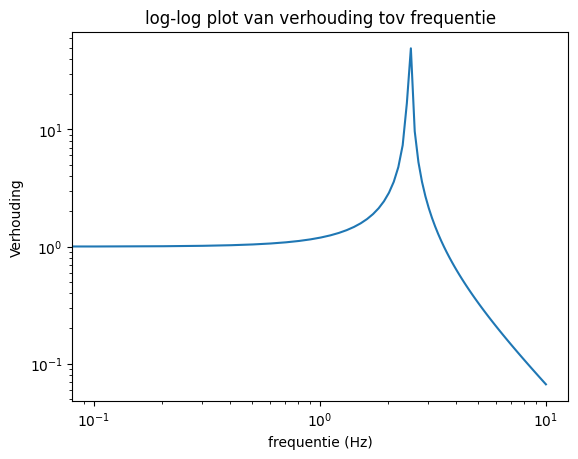

In [31]:
def verhoudingsfunctie(f, omega0):
    return np.abs(1 / (1 - ((2*np.pi*f)**2) / (omega0**2)))

frequentie_voor_x = np.linspace(0,10,100)

resultaat = verhoudingsfunctie(frequentie_voor_x, omega0)

plt.figure
plt.plot(frequentie_voor_x, resultaat)
plt.title("log-log plot van verhouding tov frequentie")
plt.xscale('log')
plt.xlabel("frequentie (Hz)")
plt.yscale('log')
plt.ylabel("Verhouding")
plt.show

In [32]:
g = 9.812

dx = g / omega0**2

print("deltax = ", dx, "meter")

deltax =  0.039766538155944726 meter


## Opdracht 3: Plot de grafiek.

<function matplotlib.pyplot.show(close=None, block=None)>

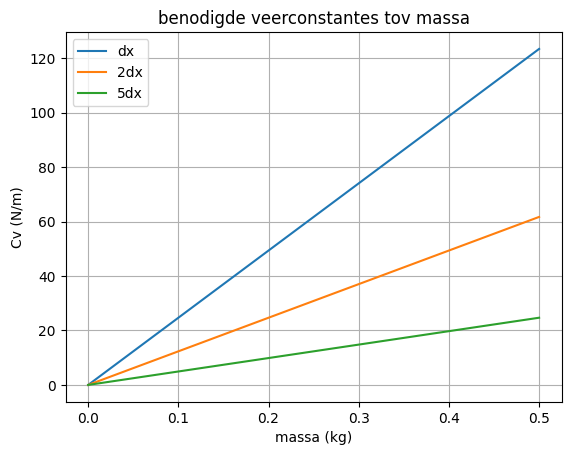

In [45]:
# Voeg hier je plot in. Lees goed de opdracht wat er in de grafiek moet staan!
# Het is ook handig om je grafiek op te slaan, doe dat door met plt.savefig().

def massaveer(m):
    return (m * g) / dx

massavoorx = np.linspace(0,0.5,5000)
veerconstantes = massaveer(massavoorx)

plt.figure()
plt.title("benodigde veerconstantes tov massa")
plt.plot(massavoorx, veerconstantes, label="dx")
plt.plot(massavoorx, 0.5*veerconstantes, label="2dx")
plt.plot(massavoorx, 0.2*veerconstantes, label="5dx")
plt.grid()
plt.legend()
plt.xlabel("massa (kg)")
#plt.xlim(0.4,0.5)
plt.ylabel("Cv (N/m)")
plt.show

## Opdracht 4: Verander $\Delta x$.

We kunnen $\Delta x$ verhogen door:

- Massa groter
- Lagere veerconstante

Vul onderstaande aan. Geef eventueel met tekst aan waarom je hiervoor gekozen hebt, als extra informatie richting de nakijkers. 

Als groep gaan we mikken op een $\Delta x$ van: 2 keer minimum, dus dx ~ 8 cm

## Opdracht 5: Schets.

##### schets opstelling: 
<img src="schetsopstelling.jpg" width="500">

## Opdracht 6: Beslissing evaluatie

Voldoet je ontwerp aan de eisen? Beantwoord de volgende vragen:

### Wat is de $\Delta x$ van je ontwerp?

De gewenste dx is 8 cm, dit is 2 keer de minimale dx.

### Wordt die $\Delta x$ behaald met je gekozen massa en veer?

Ja, de opstelling behaald een dx van 12cm

### hoeveel verder kan je massa-veer systeem nog uitrekken / indrukken?
Wat is de limiet aan je veer / verend materiaal voordat het niet meer lineair reageert volgens de wet van Hooke?

19cm

### Is dat genoeg om straks metingen te kunnen doen?
Hou er rekening mee dat je trillingen een amplitude in de orde grote van een paar centimeter gaan hebben, minder is met deze opzet moeilijk te realiseren.

Ja, trillingen van een paar centimeter zou de opstelling aan moeten kunnen.

### Gaat je ontwerp dus voldoen aan de eis?

**Voeg hier je antwoord in.**

Als je hier positief geantwoord heb, maak dan nog een keer een plot van amplitude overdracht (y-as) versus frequentie (x-as) zoals je hierboven ook al een keer gedaan heb, maar plot nu twee verschillende overdrachten in de grafiek: één die je al had: behorende bij de grens van de ontwerp-eis en één behorende bij je eigen ontwerp. Lees af dat je voor je ontwerp daadwerkelijk onder de eis grafiek zit op de kritieke frequentie!

Deze grafiek heb je later weer nodig om je gemeten punten aan toe te voegen. Ga daarna je massa-veer systeem daadwerkelijk bouwen.

Als je hier negatief geantwoord hebt, kopieer onder deze cel dan alle cellen van Synthese tot en met Evaluation & decision en doorloop dat deel van het ontwerp proces nogmaals.

In [6]:
# Voeg hier je plot in.

## Opdracht 7: Plotten maar

In [7]:
# Voeg hier je plots in.

## Opdracht 8: Leerdoelen
Voeg hieronder zelf kopjes toe om aan te geven wat bij welk leerdoel hoort. 

In [8]:
# Als je met Python je resultaten wil laten zien: voeg hier je code in.

#### Als je je figuren onderweg opgeslagen hebt, kan je ze hier invoegen:
<img src="tudelftLogo.png" width="400">
<img src="tudelftLogo.png" width="400">